# LeetCode #731: My Calendar II

https://leetcode.com/problems/my-calendar-ii/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (two lists)** | $O(n^2)$ total | $O(n)$ |
| **Optimal: Difference Array ★** | $O(n^2)$ total | $O(n)$ |

---

## Understanding the Methods

### Brute Force (two lists)
Maintain a list of single-booked intervals and a list of double-booked intervals. For each new booking, check against double-booked list first, then merge with single-booked. Same asymptotic cost but more bookkeeping.

### Optimal: Difference Array ★
Use a sorted map of delta changes: add $+1$ at `start` and $-1$ at `end` for each booking. To verify a new booking, scan the prefix sum — if it ever reaches 3 at any point, the booking causes a triple overlap and is rejected; otherwise, deltas are committed. Both approaches are $O(n^2)$ per booking, but the difference array requires fewer conditionals and generalises to $k$-booking variants trivially.

**Why this is better than Brute Force:** The difference-array model handles arbitrary $k$-booking with a single threshold check, whereas the two-list approach requires restructuring for each new $k$.

**Constraints:**
* At most $10^3$ calls to `book`
* $0 \le \text{start} < \text{end} \le 10^9$


## Solutions

### C#

In [ ]:
public class MyCalendarTwo {
    // Sorted delta map: +1 at start, -1 at end for each booked interval
    private SortedDictionary<int, int> delta = new SortedDictionary<int, int>();
    public bool Book(int start, int end) {
        delta.TryGetValue(start, out int s); delta[start] = s + 1;
        delta.TryGetValue(end,   out int e); delta[end]   = e - 1;
        // Scan prefix sum; reject if any time point reaches triple-booking
        int cur = 0;
        foreach (var v in delta.Values) {
            cur += v;
            if (cur >= 3) { delta[start]--; delta[end]++; return false; }
        }
        return true;
    }
}

### Python

In [ ]:
class MyCalendarTwo:
    def __init__(self):
        # Sorted delta map: +1 at start, -1 at end for each booked interval
        self.delta: dict[int, int] = {}

    def book(self, start: int, end: int) -> bool:
        self.delta[start] = self.delta.get(start, 0) + 1
        self.delta[end]   = self.delta.get(end,   0) - 1
        # Scan prefix sum; reject if any time point reaches triple-booking
        cur = 0
        for v in sorted(self.delta):
            cur += self.delta[v]
            if cur >= 3:
                self.delta[start] -= 1
                self.delta[end]   += 1
                return False
        return True

### Go

In [ ]:
import "sort"

type MyCalendarTwo struct {
    // Sorted delta map: +1 at start, -1 at end for each booked interval
    delta map[int]int
}

func Constructor() MyCalendarTwo {
    return MyCalendarTwo{delta: make(map[int]int)}
}

func (mc *MyCalendarTwo) Book(start int, end int) bool {
    mc.delta[start]++
    mc.delta[end]--
    // Gather and sort keys for prefix sum scan
    keys := make([]int, 0, len(mc.delta))
    for k := range mc.delta { keys = append(keys, k) }
    sort.Ints(keys)
    cur := 0
    for _, k := range keys {
        cur += mc.delta[k]
        // Reject if any time point reaches triple-booking
        if cur >= 3 { mc.delta[start]--; mc.delta[end]++; return false }
    }
    return true
}

### Rust

In [ ]:
use std::collections::BTreeMap;

struct MyCalendarTwo {
    // BTreeMap keeps keys sorted; +1 at start, -1 at end
    delta: BTreeMap<i32, i32>,
}

impl MyCalendarTwo {
    fn new() -> Self {
        MyCalendarTwo { delta: BTreeMap::new() }
    }

    fn book(&mut self, start: i32, end: i32) -> bool {
        *self.delta.entry(start).or_insert(0) += 1;
        *self.delta.entry(end).or_insert(0)   -= 1;
        // Scan prefix sum; reject if any time point reaches triple-booking
        let mut cur = 0;
        for &v in self.delta.values() {
            cur += v;
            if cur >= 3 {
                *self.delta.entry(start).or_insert(0) -= 1;
                *self.delta.entry(end).or_insert(0)   += 1;
                return false;
            }
        }
        true
    }
}

## Example Scenarios

**1. Common Case**
**Input:** `book(10,20)`, `book(50,60)`, `book(10,40)`
After first two: delta = {10:+1,20:-1,50:+1,60:-1}. Third adds {10:+2,20:-1,40:-1,...}. Prefix sum peaks at 2 < 3 → accepted. All three bookings succeed.

**2. Slightly Complex**
**Input:** `book(10,20)`, `book(15,25)`, `book(20,30)`, `book(5,15)`
First three accepted. Fourth [5,15): prefix sum at 10 → 1+1+1=3 (overlap with [10,20) and [15,25)) → rejected.

**3. Edge Case: Time Factor**
**Input:** 1,000 bookings all sharing a common midpoint
Every booking adds two entries to the delta map. After 2 bookings the midpoint has prefix sum 2; the 3rd that covers it is rejected. Each scan traverses the full sorted delta map of size $O(n)$, giving $O(n^2)$ total.

**4. Edge Case: Space Factor**
**Input:** 1,000 non-overlapping bookings
All are accepted; the delta map grows to 2,000 entries. Each scan traverses the entire map — no savings from early exit. Demonstrates worst-case $O(n)$ space.

**5. Almost-Impossible but Plausible**
**Input:** `book(0, 10^9)` three times
First two succeed (prefix sum = 2). Third: delta at 0 would reach 3 → rejected immediately on first key. The difference array detects the conflict in a single step.


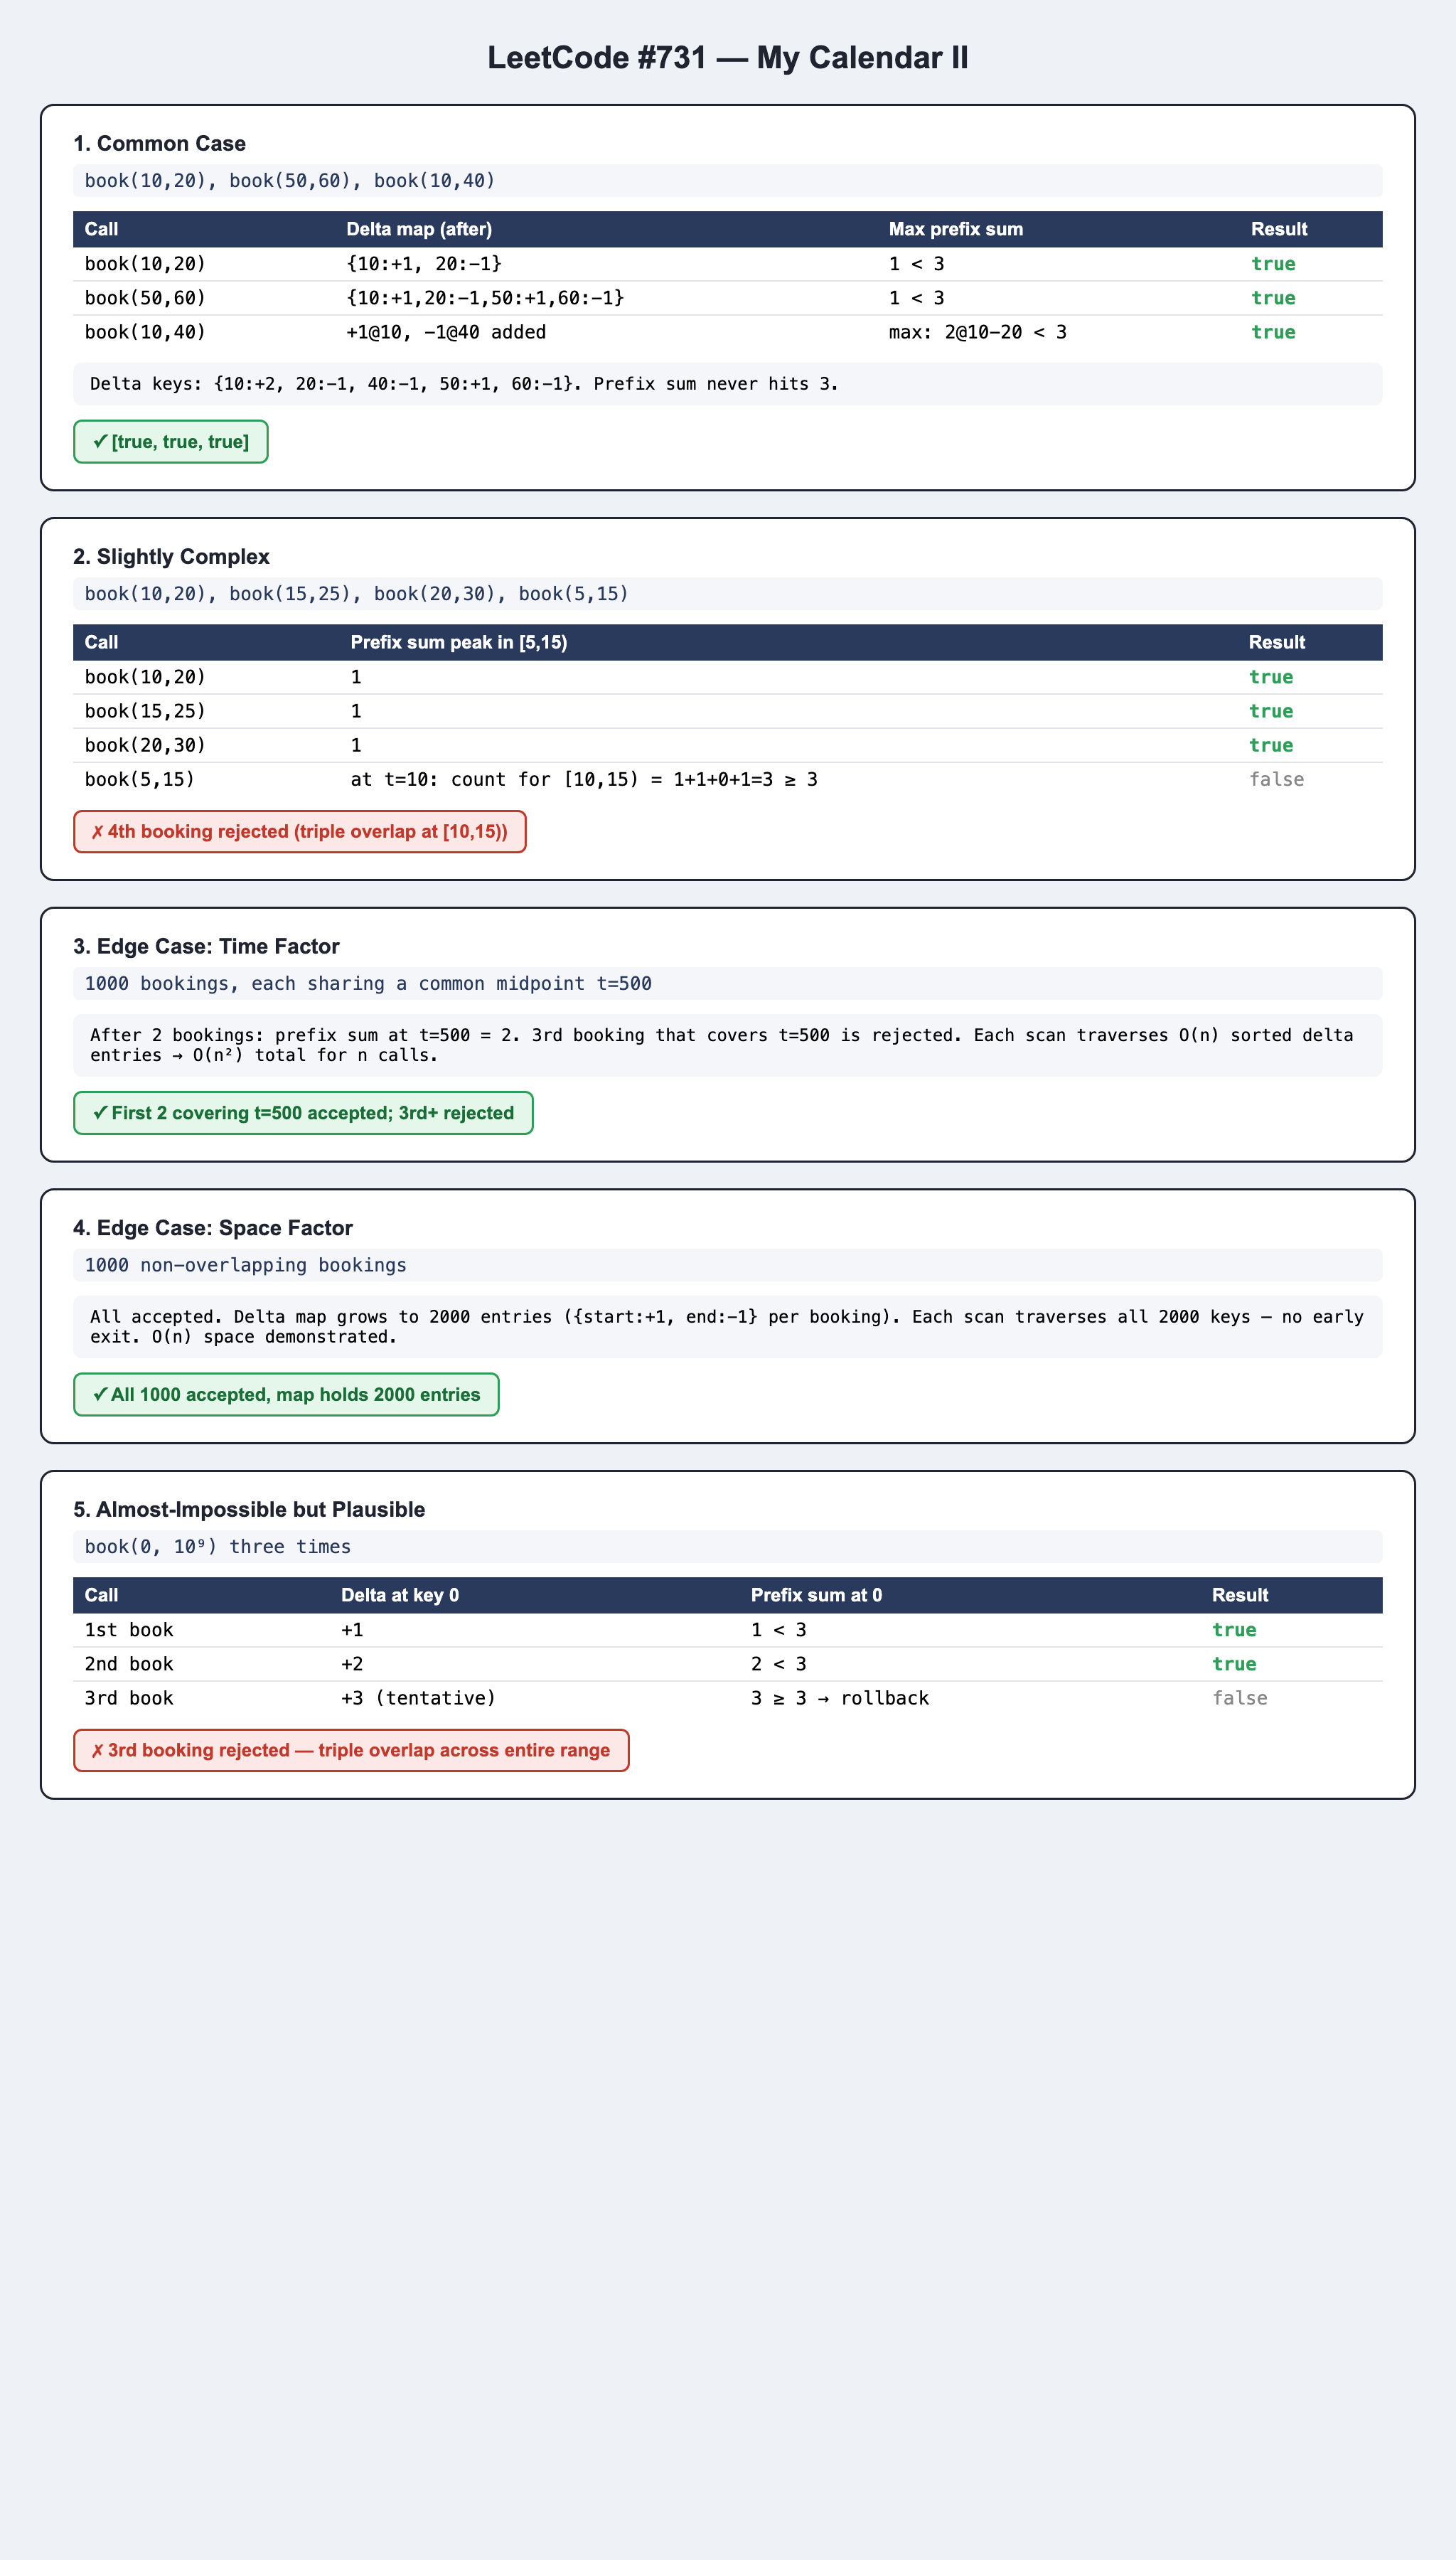